# Projet Morel : Scoring pour Service Solution Client — Prédiction & Export

**Version corrigée** — voir la cellule suivante pour le détail des correctifs.

## Résumé des correctifs apportés

1. **Cellule cassée réparée.** L'ancienne cellule d'entraînement du modèle épuré était tronquée
   (`mlflow.log_param("seuil_decision_optimal", mei` — parenthèse jamais fermée), ce qui provoquait
   une `SyntaxError` bloquant tout le notebook. Elle est remplacée par une unique cellule complète
   et fonctionnelle (l'ancienne version dupliquait de toute façon le même travail deux fois,
   avec des plages de seuils testées incohérentes entre les deux copies : 0.10–0.90 puis 0.10–0.80).
2. **Notebook rendu autonome.** `param_dist_xgb` et `cv_stratifie` étaient utilisés sans jamais être
   définis dans ce notebook (hérités par erreur d'un état de kernel du notebook précédent) —
   ce notebook plantait avec un `NameError` dès qu'on l'exécutait seul ou après un redémarrage
   du kernel. Ils sont maintenant définis ici.
3. **Autologging retiré.** `mlflow.sklearn.autolog()` / `mlflow.xgboost.autolog()` avaient été
   remis, combinés à `n_jobs=-1` dans `RandomizedSearchCV` — c'est exactement la cause du
   `BrokenProcessPool` rencontré précédemment sous Windows. Tout est de nouveau loggué
   manuellement (déjà suffisant).
4. **Ordre des opérations corrigé.** Le scoring des prospects avait lieu *avant* que le modèle
   épuré (20 features) ne soit choisi comme modèle de production — le livrable utilisait donc le
   mauvais modèle. Le scoring se fait maintenant *après* la décision finale de production.
5. **Export réellement effectué.** Le notebook s'appelle *predict_and_export* mais ne sauvegardait
   jamais `livrable_commercial` sur disque (seulement un `print`). Un vrai `.to_csv(...)` a été ajouté.
6. **Décision de production justifiée, pas automatique.** Le modèle épuré (20 features) n'est adopté
   en production que s'il n'est pas significativement moins bon que le modèle complet (comparaison
   d'AUC récupérée directement depuis l'historique MLflow) — sinon le modèle complet est conservé.
7. **Nettoyage** : liste de colonnes à exclure limitée aux colonnes réellement présentes dans le CSV
   (`SOCIETE`, `Score_Pred_BERA_M`, `Priorité_Appel` n'existent pas et ont été retirés), suppression
   du chargement local mort du `.pkl` (écrasé de toute façon par le chargement MLflow juste après),
   suppression des cellules dupliquées, import inutilisé de `StandardScaler` retiré.


# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os
import gc
import json
import joblib
import mlflow
import mlflow.sklearn

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from xgboost import XGBClassifier

from datetime import datetime


c:\Users\15GIRAV\Moi\Boulot\OpenClassrooms\P8_Confirmez_vos_competences_en_MLOPS_partie_2_2\.venv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# MLflow — configuration

In [2]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Même expérience que le notebook d'entraînement, pour garder tout l'historique
# du projet comparable au même endroit dans l'UI MLflow.
EXPERIMENT_NAME = "Projet_Morel_Scoring_BERA_M"
mlflow.set_experiment(EXPERIMENT_NAME)

# Sécurité : on ferme de force toute session restée ouverte par erreur
mlflow.end_run()

print(f"✅ Configuration MLflow initialisée (expérience : '{EXPERIMENT_NAME}').")


✅ Configuration MLflow initialisée (expérience : 'Projet_Morel_Scoring_BERA_M').


**Toujours pas d'autologging.** Pour la même raison que dans le notebook d'entraînement :
`mlflow.sklearn.autolog()` combiné à `RandomizedSearchCV(n_jobs=-1)` est une cause connue de
`BrokenProcessPool` sous Windows. Tout est loggué manuellement ci-dessous.


# Chargement des données et du modèle de production actuel

In [3]:
df_final_model_enriched = pd.read_csv('df_final_model_enriched.csv', low_memory=False)
df_final_model_enriched.head()


,Unnamed: 0,Famille_6_N_signature_1,Nb_lignes_N_signature_2,Panier_Moyen_N_signature_4,Turnover_N_signature_3,Famille_10_N_signature_2,Famille_0_N_signature_1,Famille_1_N_signature_4,Famille_10_N_signature_4,division,...,customer_value_score,branche,clp_contrat_ap_stat,annees_depuis_1ere_facture,annees_depuis_dernier_achat,code_departemental,pot_40_calc,GrandCompte,NOTE_COFACE,%EC
0,0,0.0,311.0,0,3406.010010,31.0,39.0,14.0,18.0,15-001,...,69.0,4903.0,BK,21.0,0.0,22.0,18421.0,True,6.0,87.7
1,1,0.0,115.0,0,6519.359863,7.0,1.0,3.0,21.0,15-001,...,96.0,4078.0,BK,21.0,0.0,82.0,18421.0,True,4.0,9.2
2,2,0.0,296.0,0,13298.250000,19.0,138.0,58.0,32.0,15-000,...,88.0,5237.0,BK,21.0,0.0,22.0,7875.0,True,7.0,6.3
3,3,0.0,68.0,0,2190.709961,12.0,7.0,0.0,0.0,15-011,...,80.0,3001.0,AE,21.0,0.0,24.0,7143.0,True,3.0,47.9
4,4,0.0,79.0,0,801.880005,9.0,7.0,0.0,13.0,15-011,...,47.0,3003.0,NaN,21.0,0.0,83.0,5357.0,True,9.0,0.0


In [4]:
df_final_model_enriched = df_final_model_enriched.drop(columns=['Unnamed: 0'])
df_final_model_enriched.head()

,Famille_6_N_signature_1,Nb_lignes_N_signature_2,Panier_Moyen_N_signature_4,Turnover_N_signature_3,Famille_10_N_signature_2,Famille_0_N_signature_1,Famille_1_N_signature_4,Famille_10_N_signature_4,division,Turnover_N_signature_2,...,customer_value_score,branche,clp_contrat_ap_stat,annees_depuis_1ere_facture,annees_depuis_dernier_achat,code_departemental,pot_40_calc,GrandCompte,NOTE_COFACE,%EC
0,0.0,311.0,0,3406.010010,31.0,39.0,14.0,18.0,15-001,7023.759766,...,69.0,4903.0,BK,21.0,0.0,22.0,18421.0,True,6.0,87.7
1,0.0,115.0,0,6519.359863,7.0,1.0,3.0,21.0,15-001,7214.049805,...,96.0,4078.0,BK,21.0,0.0,82.0,18421.0,True,4.0,9.2
2,0.0,296.0,0,13298.250000,19.0,138.0,58.0,32.0,15-000,12811.910156,...,88.0,5237.0,BK,21.0,0.0,22.0,7875.0,True,7.0,6.3
3,0.0,68.0,0,2190.709961,12.0,7.0,0.0,0.0,15-011,5540.299805,...,80.0,3001.0,AE,21.0,0.0,24.0,7143.0,True,3.0,47.9
4,0.0,79.0,0,801.880005,9.0,7.0,0.0,13.0,15-011,2259.689941,...,47.0,3003.0,NaN,21.0,0.0,83.0,5357.0,True,9.0,0.0


In [5]:
# On charge le modèle depuis le registre MLflow (source de vérité pour la production),
# et non depuis un fichier .pkl local qui pourrait être désynchronisé.
model_uri = "models:/XGBoost_BERA_Pipeline/latest"
best_pipeline = mlflow.sklearn.load_model(model_uri)

print("✅ Modèle de production chargé depuis MLflow :", model_uri)


✅ Modèle de production chargé depuis MLflow : models:/XGBoost_BERA_Pipeline/latest


# Préparation des features (identique au notebook d'entraînement)

In [6]:
# Seules les colonnes réellement présentes dans le CSV et non-pertinentes pour le modèle
# sont exclues : identifiants, cible, et score externe NOTE_COFACE.
colonnes_a_exclure = ["code_client", "compagny", "is_BERA_M", "NOTE_COFACE"]
features_model = [col for col in df_final_model_enriched.columns if col not in colonnes_a_exclure]

X = df_final_model_enriched[features_model].copy()
y = df_final_model_enriched["is_BERA_M"].astype(int)

colonnes_cat = [col for col in X.columns if X[col].dtype == 'object' or X[col].dtype.name == 'category']
for col in colonnes_cat:
    X[col] = X[col].astype('category')

# Même random_state que le notebook d'entraînement : split reproductible et cohérent
# avec celui utilisé pour évaluer le modèle en production actuel.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Structure de l'entraînement (X_train) : {X_train.shape}")
print(f"Structure du test (X_test) : {X_test.shape}")


Structure de l'entraînement (X_train) : (145649, 83)
Structure du test (X_test) : (36413, 83)


# Feature importance

C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_5320\759821897.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Importance", y="Feature", data=df_importances, palette="Blues_r")


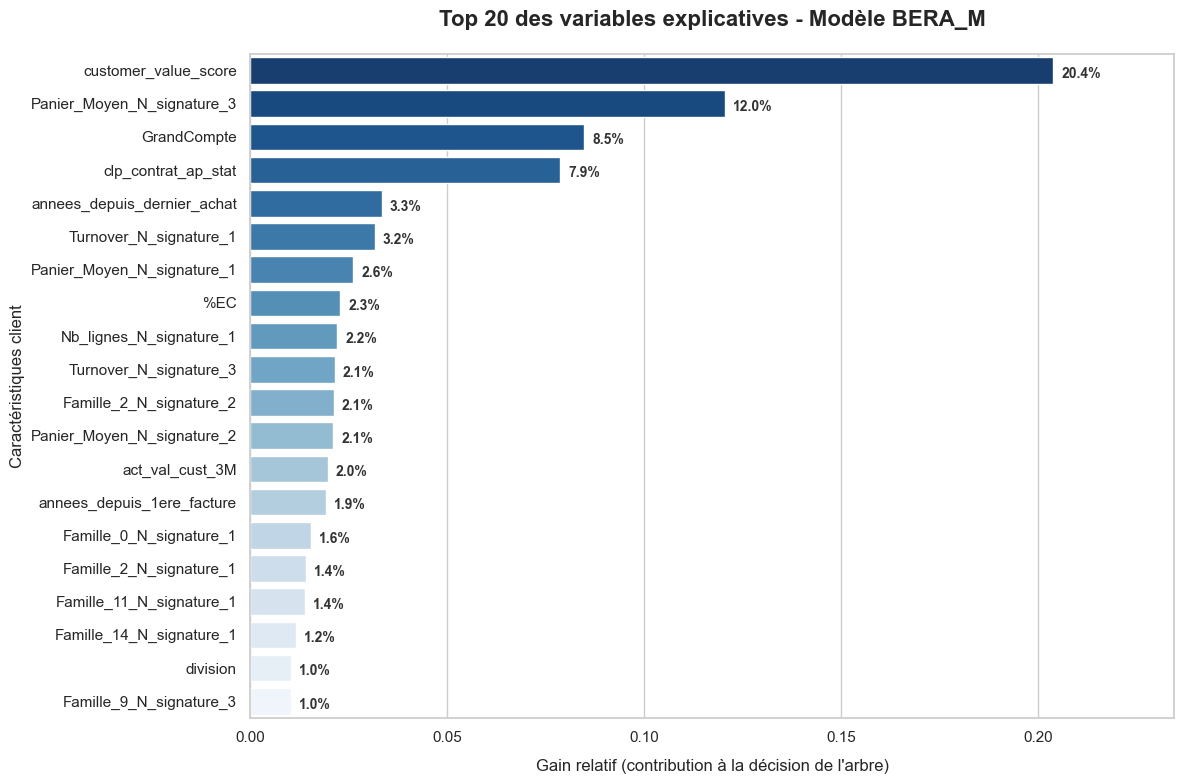

In [7]:
model_xgb = best_pipeline.named_steps["xgb"]
importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

top_n = 20
df_importances = importances.head(top_n).reset_index()
df_importances.columns = ['Feature', 'Importance']

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x="Importance", y="Feature", data=df_importances, palette="Blues_r")

for p in ax.patches:
    width = p.get_width()
    if width > 0.001:
        ax.text(width + 0.002, p.get_y() + p.get_height() / 2 + 0.1,
                f'{width * 100:.1f}%', ha="left", va="center", fontsize=10, fontweight='bold', color='#333333')

plt.title(f"Top {top_n} des variables explicatives - Modèle BERA_M", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Gain relatif (contribution à la décision de l'arbre)", fontsize=12, labelpad=10)
plt.ylabel("Caractéristiques client", fontsize=12)
plt.xlim(0, df_importances['Importance'].max() * 1.15)
plt.tight_layout()
plt.show()


Une grande partie des features a une importance inférieure à 1%. On va tester un modèle réduit à ces 20 variables principales — **à condition de vérifier que ça ne dégrade pas significativement la performance** (voir la comparaison d'AUC après le réentraînement, plus bas).

# Réduction des variables et réentraînement

In [8]:
features_model_epure = df_importances["Feature"].tolist()
colonnes_cat_epure = [col for col in colonnes_cat if col in features_model_epure]

X_train_epure = X_train[features_model_epure].copy()
X_test_epure = X_test[features_model_epure].copy()

print(f"📉 Nombre de variables initiales : {len(X_train.columns)}")
print(f"🎯 Nombre de variables conservées (Top {top_n}) : {len(features_model_epure)}")
print(f"🔤 Dont variables catégorielles à encoder : {len(colonnes_cat_epure)} {colonnes_cat_epure}")


📉 Nombre de variables initiales : 83
🎯 Nombre de variables conservées (Top 20) : 20
🔤 Dont variables catégorielles à encoder : 2 ['division', 'clp_contrat_ap_stat']


In [9]:
# Hypothèses de coût métier (mêmes valeurs que le notebook d'entraînement)
cout_appel_inutile = 20    # coût d'un appel inutile (faux positif)
gain_contrat_rate = 1500   # manque à gagner d'un client manqué (faux négatif)


In [10]:
# Grille et schéma de validation croisée définis ICI pour que ce notebook soit autonome
# (ne dépend plus d'un état de kernel laissé par le notebook d'entraînement).
param_dist_xgb = {
    "smote__sampling_strategy": [0.25, 0.5, "auto"],
    "xgb__n_estimators": [100, 150, 200],
    "xgb__max_depth": [3, 4, 5, 6],
    "xgb__learning_rate": [0.05, 0.1, 0.2],
}

cv_stratifie = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [11]:
os.makedirs("../models", exist_ok=True)

print("🚀 Réentraînement du pipeline épuré (Top 20 features)...")

new_pipeline_xgb = Pipeline([
    ("encoder", TargetEncoder(cols=colonnes_cat_epure)),
    ("imputer", SimpleImputer(strategy='median')),
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier(random_state=42, n_jobs=1, eval_metric="logloss")),
])

with mlflow.start_run(run_name="XGBoost_Pipeline_Epure_Top20") as run_epure:

    # ------------------------------------------------------------
    # 1. Entraînement
    # ------------------------------------------------------------
    random_search_xgb_epure = RandomizedSearchCV(
        estimator=new_pipeline_xgb,
        param_distributions=param_dist_xgb,
        n_iter=15, scoring="roc_auc", cv=cv_stratifie,
        random_state=42, n_jobs=1, verbose=1,
    )
    random_search_xgb_epure.fit(X_train_epure, y_train)
    best_pipeline_epure = random_search_xgb_epure.best_estimator_

    for param_name, param_value in random_search_xgb_epure.best_params_.items():
        mlflow.log_param(param_name, param_value)
    mlflow.log_param("nombre_features", len(features_model_epure))

    # ------------------------------------------------------------
    # 2. Évaluation + seuil de décision optimal (coût métier)
    # ------------------------------------------------------------
    y_score_epure = best_pipeline_epure.predict_proba(X_test_epure)[:, 1]
    auc_test_epure = roc_auc_score(y_test, y_score_epure)

    seuils_testes = np.arange(0.05, 0.96, 0.01)
    couts = []
    for seuil in seuils_testes:
        y_pred_s = (y_score_epure >= seuil).astype(int)
        cm_s = confusion_matrix(y_test, y_pred_s)
        fp_s = cm_s[0, 1] if cm_s.shape == (2, 2) else 0
        fn_s = cm_s[1, 0] if cm_s.shape == (2, 2) else 0
        couts.append(fp_s * cout_appel_inutile + fn_s * gain_contrat_rate)
    couts = np.array(couts)
    meilleur_seuil_epure = float(seuils_testes[np.argmin(couts)])
    cout_min_epure = float(couts.min())

    mlflow.log_metric("auc_test", auc_test_epure)
    mlflow.log_metric("cout_total_erreurs_euros", cout_min_epure)
    mlflow.log_param("seuil_decision_optimal", meilleur_seuil_epure)

    print(f"✨ AUC test (modèle épuré) : {auc_test_epure:.4f}")
    print(f"🎯 Seuil optimal : {meilleur_seuil_epure:.2f} | Coût min : {cout_min_epure:.0f} €")

    # ------------------------------------------------------------
    # 3. Sauvegarde — DANS le run actif
    # ------------------------------------------------------------
    mlflow.sklearn.log_model(
        sk_model=best_pipeline_epure,
        artifact_path="pipeline_model_epure",
        serialization_format="cloudpickle",
        registered_model_name="XGBoost_BERA_Pipeline_Epure",
    )
    joblib.dump(best_pipeline_epure, "../models/best_pipeline_xgboost_epure.pkl")

    df_pred_epure = pd.DataFrame({
        'True_Label': y_test.values,
        'Predicted_Label': (y_score_epure >= meilleur_seuil_epure).astype(int),
        'Probability_Class_1': y_score_epure,
    })
    file_epure = "predictions_epure_model.csv"
    df_pred_epure.to_csv(file_epure, index=False)
    mlflow.log_artifact(file_epure, artifact_path="predictions")
    os.remove(file_epure)

    run_id_epure = run_epure.info.run_id

print(f"\n✅ Run MLflow (modèle épuré) : {run_id_epure}")


🚀 Réentraînement du pipeline épuré (Top 20 features)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits


2026/07/30 09:47:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/30 09:47:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✨ AUC test (modèle épuré) : 0.9886
🎯 Seuil optimal : 0.05 | Coût min : 39540 €

✅ Run MLflow (modèle épuré) : 155f960f53254dcda942ced8f5b2a937


Registered model 'XGBoost_BERA_Pipeline_Epure' already exists. Creating a new version of this model...
Created version '4' of model 'XGBoost_BERA_Pipeline_Epure'.


# Passage en production : comparaison avant de décider

Le modèle épuré n'est adopté que s'il n'est **pas significativement moins bon** que le modèle
complet déjà en production (on tolère jusqu'à 1 point d'AUC de moins, en échange d'un modèle plus
simple avec 4x moins de variables). Sinon, on garde le modèle complet.


In [12]:
# Récupération de l'AUC du modèle complet actuellement en production, directement
# depuis l'historique MLflow (pas besoin de le réentraîner ni de le recharger en mémoire).
runs_original = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    filter_string="tags.mlflow.runName = 'XGBoost_Final_Optimise'",
    order_by=["start_time DESC"],
)

TOLERANCE_AUC = 0.01

if not runs_original.empty and "metrics.auc_test" in runs_original.columns:
    auc_original = runs_original.iloc[0]["metrics.auc_test"]
    print(f"AUC modèle complet ({len(X_train.columns)} features) : {auc_original:.4f}")
    print(f"AUC modèle épuré ({len(features_model_epure)} features)  : {auc_test_epure:.4f}")
    print(f"Écart : {auc_test_epure - auc_original:+.4f}")

    adopter_modele_epure = (auc_test_epure >= auc_original - TOLERANCE_AUC)
else:
    print("⚠️ Impossible de retrouver le run du modèle complet dans MLflow — "
          "on adopte le modèle épuré par défaut, à vérifier manuellement.")
    adopter_modele_epure = True

if adopter_modele_epure:
    print("\n✅ Décision : on passe en production le modèle ÉPURÉ (plus simple, performance comparable).")
    best_pipeline_prod = best_pipeline_epure
    features_model_prod = features_model_epure
    colonnes_cat_prod = colonnes_cat_epure
    seuil_production = meilleur_seuil_epure
else:
    print("\n✅ Décision : on GARDE le modèle complet (le modèle épuré perd trop d'AUC).")
    best_pipeline_prod = best_pipeline
    features_model_prod = features_model
    colonnes_cat_prod = colonnes_cat
    seuil_production = 0.5  # à défaut d'un seuil optimisé déjà calculé pour le modèle complet ici


AUC modèle complet (83 features) : 0.9893
AUC modèle épuré (20 features)  : 0.9886
Écart : -0.0007

✅ Décision : on passe en production le modèle ÉPURÉ (plus simple, performance comparable).


In [13]:
# Assure-toi que le dossier existe
os.makedirs("../models", exist_ok=True)

# Sauvegarde le VRAI modèle retenu pour la prod
joblib.dump(best_pipeline_prod, "../models/best_pipeline_production.joblib")
print("💾 Modèle de production sauvegardé avec succès dans '../models/best_pipeline_production.joblib'")

💾 Modèle de production sauvegardé avec succès dans '../models/best_pipeline_production.joblib'


# Scoring des prospects

**Fait avec le modèle finalement retenu pour la production** (`best_pipeline_prod`), pas avec
un modèle intermédiaire — c'est le principal bug corrigé par rapport à la version précédente.


In [14]:
print("🎯 Isolation de la population cible (prospects non-signataires)...")

df_prospects = df_final_model_enriched[df_final_model_enriched["is_BERA_M"] == 0].copy()
X_prospects = df_prospects[features_model_prod].copy()

for col in colonnes_cat_prod:
    X_prospects[col] = X_prospects[col].astype('category')

print("🔮 Calcul des probabilités d'achat (scoring)...")
df_prospects["Score_Appetence_BERA_M"] = best_pipeline_prod.predict_proba(X_prospects)[:, 1]

# Bornes de priorité calées sur le seuil optimal métier retenu, pas des valeurs arbitraires.
seuil_bas = seuil_production * 0.6
seuil_haut = seuil_production * 1.3

def assigner_priorite(score):
    if score >= seuil_haut:
        return "1 - TOP PRIORITÉ"
    elif score >= seuil_bas:
        return "2 - PRIORITÉ MOYENNE"
    else:
        return "3 - BASSE PRIORITÉ"

df_prospects["Priorite_Appel"] = df_prospects["Score_Appetence_BERA_M"].apply(assigner_priorite)

colonnes_export = [
    "code_client", "compagny", "division", "branche",
    "NOTE_COFACE", "%EC", "Score_Appetence_BERA_M", "Priorite_Appel",
]

livrable_commercial = df_prospects[colonnes_export].sort_values(
    by="Score_Appetence_BERA_M", ascending=False
)

print(f"\n✅ Traitement terminé. Nombre de prospects scorés : {livrable_commercial.shape[0]}")
print("\n--- APERÇU DES 10 MEILLEURS PROSPECTS À CIBLER ---")
print(livrable_commercial.head(10).to_string(index=False))


🎯 Isolation de la population cible (prospects non-signataires)...
🔮 Calcul des probabilités d'achat (scoring)...

✅ Traitement terminé. Nombre de prospects scorés : 180830

--- APERÇU DES 10 MEILLEURS PROSPECTS À CIBLER ---
code_client compagny division  branche  NOTE_COFACE  %EC  Score_Appetence_BERA_M   Priorite_Appel
 1531486000     FR15   15-011   2000.0          6.0  0.0                0.925652 1 - TOP PRIORITÉ
 1512979700     FR15   15-010   1110.0          8.0 52.0                0.915694 1 - TOP PRIORITÉ
 1593120000     FR15   15-001   4509.0          7.0 27.3                0.900494 1 - TOP PRIORITÉ
 1560253500     FR15   15-001   4027.0          6.0  2.0                0.895718 1 - TOP PRIORITÉ
 1529382200     FR15   15-010   2940.0          8.0  0.0                0.876445 1 - TOP PRIORITÉ
 1551439000     FR15   15-010   1110.0          6.0  0.0                0.835704 1 - TOP PRIORITÉ
 1528731300     FR15   15-010   1999.0          2.0  0.0                0.835299 1 - TOP P

In [15]:
# Export réel sur disque
nom_fichier_export = f"livrable_commercial_scoring_BERA_M_{datetime.now():%Y%m%d}.csv"
livrable_commercial.to_csv(nom_fichier_export, index=False)
print(f"💾 Livrable exporté : '{nom_fichier_export}'")


💾 Livrable exporté : 'livrable_commercial_scoring_BERA_M_20260730.csv'


# Vérification finale

In [16]:
# On sauvegarde aussi la liste de features + le seuil de production en artefact JSON,
# pour éviter qu'un futur notebook ait à re-taper cette liste à la main (source de bugs
# rencontrée plusieurs fois jusqu'ici : listes de colonnes désynchronisées entre notebooks).
config_production = {
    "features_model": features_model_prod,
    "colonnes_cat": colonnes_cat_prod,
    "seuil_production": seuil_production,
}
with open("../models/config_production.json", "w", encoding="utf-8") as f:
    json.dump(config_production, f, ensure_ascii=False, indent=2)

print("💾 Configuration de production sauvegardée : '../models/config_production.json'")


💾 Configuration de production sauvegardée : '../models/config_production.json'


In [17]:
print(json.dumps(config_production, ensure_ascii=False, indent=2))

{
  "features_model": [
    "customer_value_score",
    "Panier_Moyen_N_signature_3",
    "GrandCompte",
    "clp_contrat_ap_stat",
    "annees_depuis_dernier_achat",
    "Turnover_N_signature_1",
    "Panier_Moyen_N_signature_1",
    "%EC",
    "Nb_lignes_N_signature_1",
    "Turnover_N_signature_3",
    "Famille_2_N_signature_2",
    "Panier_Moyen_N_signature_2",
    "act_val_cust_3M",
    "annees_depuis_1ere_facture",
    "Famille_0_N_signature_1",
    "Famille_2_N_signature_1",
    "Famille_11_N_signature_1",
    "Famille_14_N_signature_1",
    "division",
    "Famille_9_N_signature_3"
  ],
  "colonnes_cat": [
    "division",
    "clp_contrat_ap_stat"
  ],
  "seuil_production": 0.05
}


In [18]:
X_train_epure.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145649 entries, 165420 to 83410
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   customer_value_score         72168 non-null   float64 
 1   Panier_Moyen_N_signature_3   145649 non-null  float64 
 2   GrandCompte                  145649 non-null  bool    
 3   clp_contrat_ap_stat          28851 non-null   category
 4   annees_depuis_dernier_achat  145649 non-null  float64 
 5   Turnover_N_signature_1       145649 non-null  float64 
 6   Panier_Moyen_N_signature_1   145649 non-null  float64 
 7   %EC                          145649 non-null  float64 
 8   Nb_lignes_N_signature_1      145649 non-null  float64 
 9   Turnover_N_signature_3       145649 non-null  float64 
 10  Famille_2_N_signature_2      145649 non-null  float64 
 11  Panier_Moyen_N_signature_2   145649 non-null  float64 
 12  act_val_cust_3M              145649 non-null 

In [19]:
# ==========================================================
# EXPORT DU JEU DE RÉFÉRENCE POUR LE MONITORING (Evidently)
# ==========================================================
from pathlib import Path

# Le notebook tourne depuis un dossier notebooks/, donc on remonte d'un niveau
# pour retrouver la racine du projet (là où analyze_drift.py attend data/processed/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

X_train_ref_export = X_train_epure.copy()
# On garde le typage catégoriel tel qu'attendu par le pipeline / l'API en aval
for col in colonnes_cat_epure:
    X_train_ref_export[col] = X_train_ref_export[col].astype("object")

X_train_ref_export.to_csv(PROCESSED_DIR / "X_train.csv", index=False)
print(f"💾 Référence de monitoring exportée : {PROCESSED_DIR / 'X_train.csv'} "
      f"({X_train_ref_export.shape[0]} lignes, {X_train_ref_export.shape[1]} colonnes)")

💾 Référence de monitoring exportée : c:\Users\15GIRAV\Moi\Boulot\OpenClassrooms\P8_Confirmez_vos_competences_en_MLOPS_partie_2_2\data\processed\X_train.csv (145649 lignes, 20 colonnes)
